In [1]:
rm(list = ls())
gc()
.libPaths("/home/minghui/miniforge3/lib/R/library")

setwd('/mnt/data00/Minghui/project_NMF/08_Test_NMF_consensus_matrix_V2/')
# library(rliger)
library(dplyr)
library(cowplot)

library(Seurat)
library(ggplot2)
library(parallel)
library(foreach)
library(doParallel)
library(presto)
source('/mnt/data00/Minghui/Function/Markers_kno.R')


library(data.table)
library(clusterProfiler)
library(dplyr)
library(org.Hs.eg.db)#
library(ggplot2)
library(enrichpl)


library(enrichplot)


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,634032,33.9,1390690,74.3,1077157,57.6
Vcells,1176634,9.0,8388608,64.0,1815604,13.9



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode

Loading required package: iterators

Loading required package: Rcpp

Loading required package: data.table


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




# Processing Data

In [2]:
# load data
merge_matrix <- readRDS('./02_merge_matrix.rds') #this is matrix of gene by program of all

mat_unit <- readRDS('./02_L2morm_matrix.rds') #nomolized


In [ ]:
# to get the consense mayrix by using silhouette

library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

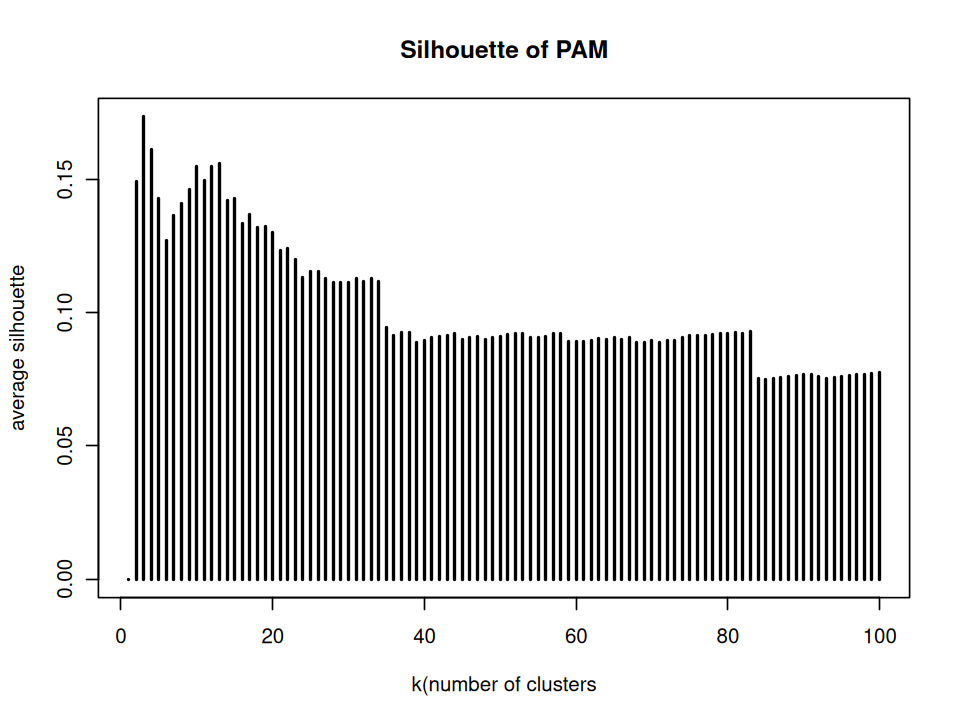

In [7]:
# caculate each average silhouette for number of clusters 
# foe chosing k value
asw <- numeric(100)
for (i in 2:100) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

In [8]:
max(asw[30:40])

which(asw== max(asw[30:40]))

[1] 0.1128548

[1] 31

In [ ]:
# use 31 as group number

k = 31

pam_data <- pam(t(mat_unit),k )

In [10]:
medoid_names <- pam_data$medoids

# Extract these columns (corresponding to medoid) from the original matrix
medoid_vectors <- mat_unit[, rownames( pam_data$medoids)]

In [211]:
head(medoid_vectors)

dim(medoid_vectors) # 3000 genes 31 programs

,GSM3954950_Program_10,SRR8513798_Program_4,Patient22_SIGAG9_NG_Program_6,Patient16_SIGAA1_GIM_Program_1,GSM3954950_Program_3,GSM3954950_Program_8,Patient03_SIGAC5_BE_Program_12,GSM3954950_Program_4,GSM3954955_Program_8,Patient02_SIGAD9_NSCJ_Program_2,⋯,Patient16_SIGAA1_GIM_Program_8,Patient16_SIGAB1_CIM_Program_12,Patient12_SIGAC3_GM_Program_6,SRR8513797_Program_6,Patient02_SIGAE9_NG_Program_2,Patient14_SIGAE8_GIM_Program_13,Patient22_SIGAG9_NG_Program_3,Patient14_SIGAE8_GIM_Program_6,Patient22_SIGAG9_NG_Program_13,SRR8513797_Program_9
MT1X,1.746553e-09,1.431572e-09,1.195476e-09,1.233519e-09,1.025300e-03,1.530731e-09,1.048068e-09,2.414184e-09,9.774643e-10,9.416661e-05,⋯,2.971291e-02,8.381327e-03,3.649697e-04,1.216080e-09,1.367471e-09,1.550497e-09,1.361838e-09,1.301801e-03,2.024175e-09,1.444019e-09
STMN1,1.204377e-05,3.871505e-03,4.710644e-03,8.240336e-03,6.468011e-03,1.530731e-09,3.470324e-02,2.414184e-09,9.702821e-03,1.119043e-02,⋯,2.021143e-02,5.377691e-03,3.339960e-03,2.364094e-02,3.628155e-03,1.161376e-02,2.047568e-03,1.459218e-02,1.464523e-02,6.066881e-03
CLU,1.746553e-09,3.045745e-02,1.195476e-09,1.233519e-09,3.766457e-04,1.530731e-09,8.308436e-03,2.414184e-09,1.342058e-03,1.291698e-03,⋯,3.212038e-03,1.482176e-09,9.923321e-10,1.216080e-09,5.147577e-02,1.550497e-09,8.210946e-03,1.484292e-09,2.024175e-09,1.179326e-01
HEPACAM2,2.007637e-03,1.431572e-09,3.560873e-03,1.233519e-09,1.675195e-02,5.270186e-02,2.574507e-08,1.604192e-02,5.753389e-02,2.006914e-02,⋯,5.833538e-03,8.134910e-03,1.149452e-02,1.216080e-09,2.034630e-02,1.560967e-02,8.179370e-02,7.154578e-03,3.423511e-03,2.703397e-02
PCSK1N,1.768999e-03,1.431572e-09,1.195476e-09,1.233519e-09,1.736337e-09,8.112904e-03,1.048068e-09,2.414184e-09,2.069423e-02,4.519678e-03,⋯,1.155401e-09,1.482176e-09,9.923321e-10,1.216080e-09,1.367471e-09,1.550497e-09,1.971086e-02,1.484292e-09,2.024175e-09,1.444019e-09
SOX4,2.513465e-03,1.431572e-09,1.195476e-09,1.233519e-09,7.222447e-03,1.530731e-09,1.048068e-09,2.414184e-09,9.774643e-10,7.150628e-03,⋯,2.787072e-02,1.556766e-02,9.923321e-10,1.216080e-09,1.849754e-02,3.092013e-02,3.450926e-03,1.683086e-02,2.024175e-09,1.444019e-09


[1] 3000   31

## Processing pathway data

In [17]:
pathway <-readRDS('/mnt/data00/Minghui/project_NMF/06_Test_NMF_Program_0213/06_KEGG_pathway.rds')

In [212]:
# kegg pathway info
head(pathway)

,Name,symbol
,<chr>,<chr>
1,Glycolysis / Gluconeogenesis,ADH1A
2,Glycolysis / Gluconeogenesis,ADH1B
3,Glycolysis / Gluconeogenesis,ADH1C
4,Glycolysis / Gluconeogenesis,ADH4
5,Glycolysis / Gluconeogenesis,ADH5
6,Glycolysis / Gluconeogenesis,ADH6


In [53]:
#here we only select glycan relate pathway
pw <- split(pathway$symbol,pathway$Name)

pw <- pw[grepl("glycan|glycosylation|O-glycan|N-glycan",names(pw), ignore.case = TRUE)]

In [52]:
pw <- pw[grepl("glycan|glycosylation|O-glycan|N-glycan",names(pw), ignore.case = TRUE)]

$`Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate`
 [1] "UST"        "B4GALT7"    "CHST14"     "B3GALT6"    "CHST13"    
 [6] "CHSY1"      "B3GAT3"     "DSE"        "CHSY3"      "CHST11"    
[11] "CHST15"     "CHPF2"      "CSGALNACT2" "CHST12"     "CSGALNACT1"
[16] "CHST7"      "XYLT1"      "XYLT2"      "CHPF"       "DSEL"      
[21] "CHST3"     

$`Glycosaminoglycan biosynthesis - heparan sulfate / heparin`
 [1] "B4GALT7"  "B3GALT6"  "EXT1"     "EXT2"     "EXTL1"    "EXTL2"   
 [7] "EXTL3"    "HS3ST5"   "GLCE"     "B3GAT3"   "HS6ST3"   "NDST1"   
[13] "XYLT1"    "XYLT2"    "NDST4"    "NDST2"    "HS6ST2"   "NDST3"   
[19] "HS6ST1"   "HS2ST1"   "HS3ST3B1" "HS3ST3A1" "HS3ST2"   "HS3ST1"  

$`Glycosaminoglycan biosynthesis - keratan sulfate`
 [1] "CHST4"   "B3GNT2"  "FUT8"    "B4GALT1" "CHST6"   "ST3GAL1" "ST3GAL2"
 [8] "ST3GAL3" "CHST1"   "B4GALT4" "B4GALT3" "B4GALT2" "B3GNT7"  "CHST2"  

$`Glycosaminoglycan degradation`
 [1] "HPSE"   "HGSNAT" "HYAL4"  "GALNS"  "GLB1"   "GNS"    "GUSB"   "HEXA"  
 [9] "HEXB"   "HYAL1"  "IDS"    "IDUA"   "ARSB"   "NAGLU"  "HPSE2"  "SGSH"  
[17] "SPAM1"  "HYAL3"  "HYAL2" 

$`Mannose type O-glycan biosynthesis`
 [1] "RXYLT1"   "POMT1"    "FUT9"     "B4GAT1"   "LARGE2"   "B3GAT2"  
 [7] "MGAT5B"   "B3GALNT2" "FKTN"     "FUT4"     "B4GALT1"  "B3GAT1"  
[13] "POMT2"    "POMGNT1"  "ST3GAL3"  "CRPPA"    "FKRP"     "POMK"    
[19] "POMGNT2"  "B4GALT3"  "B4GALT2"  "LARGE1"   "CHST10"  

$`Mucin type O-glycan biosynthesis`
 [1] "POC1B-GALNT4" "B3GNT3"       "ST6GALNAC2"   "GALNT6"       "GALNT5"      
 [6] "GALNT13"      "GALNT15"      "GALNTL5"      "B3GNT6"       "ST6GALNAC3"  
[11] "GALNT1"       "GALNT2"       "GALNT3"       "GALNT8"       "GCNT1"       
[16] "ST6GALNAC4"   "C1GALT1C1"    "GALNT18"      "GALNTL6"      "GALNT9"      
[21] "GCNT4"        "GALNT7"       "GALNT10"      "ST6GALNAC1"   "C1GALT1"     
[26] "GALNT16"      "GALNT11"      "GALNT17"      "ST3GAL1"      "ST3GAL2"     
[31] "C1GALT1C1L"   "GALNT14"      "GALNT12"      "GALNT4"       "GCNT3"       
[36] "B4GALT5"     

$`N-Glycan biosynthesis`
 [1] "ALG3"    "MAN1A2"  "MAN1B1"  "MGAT4B"  "MGAT4A"  "ALG10B"  "MGAT5B" 
 [8] "MGAT4D"  "DAD1"    "DDOST"   "DPAGT1"  "ALG14"   "KRTCAP2" "STT3B"  
[15] "DHRSX"   "DOLK"    "GANAB"   "FUT8"    "MGAT4C"  "B4GALT1" "ALG5"   
[22] "ALG6"    "STT3A"   "MAN1A1"  "MAN2A2"  "MAN2A1"  "MGAT1"   "MGAT2"  
[29] "MGAT3"   "MGAT5"   "ALG11"   "DPM3"    "ALG1"    "MAN1C1"  "DOLPP1" 
[36] "OSTC"    "RPN1"    "RPN2"    "ST6GAL1" "TMEM258" "MOGS"    "ALG8"   
[43] "ALG12"   "SRD5A3"  "ALG9"    "ALG13"   "TUSC3"   "MAGT1"   "ST6GAL2"
[50] "ALG10"   "ALG2"    "B4GALT3" "B4GALT2" "DPM1"    "DPM2"   

$`Other glycan degradation`
 [1] "NEU3"   "NEU4"   "AGA"    "MAN2B2" "FUCA1"  "FUCA2"  "GBA1"   "GLB1"  
 [9] "HEXD"   "HEXA"   "HEXB"   "MAN2C1" "MAN2B1" "MANBA"  "NEU1"   "NEU2"  
[17] "GBA2"   "ENGASE"

$`Other types of O-glycan biosynthesis`
 [1] "POC1B-GALNT4" "POMT1"        "GALNT6"       "GALNT5"       "GALNT13"     
 [6] "GALNT15"      "B3GLCT"       "XXYLT1"       "GALNTL5"      "COLGALT2"    
[11] "POFUT2"       "POFUT1"       "GALNT1"       "GALNT2"       "GALNT3"      
[16] "GALNT8"       "B4GALT1"      "GXYLT1"       "EOGT"         "C1GALT1C1"   
[21] "POMT2"        "GALNT18"      "LFNG"         "MFNG"         "GALNTL6"     
[26] "GALNT9"       "GALNT7"       "GALNT10"      "C1GALT1"      "POGLUT1"     
[31] "GALNT16"      "RFNG"         "GALNT11"      "GALNT17"      "ST6GAL1"     
[36] "ST3GAL3"      "GXYLT2"       "C1GALT1C1L"   "GALNT14"      "GALNT12"     
[41] "COLGALT1"     "ST6GAL2"      "OGT"          "GALNT4"       "B4GALT3"     
[46] "B4GALT2"      "PLOD3"       

$`Proteoglycans in cancer`
  [1] "AKT3"           "CDKN1A"         "VAV3"           "FRS2"          
  [5] "HPSE"           "P3R3URF-PIK3R3" "FZD10"          "TWIST2"        
  [9] "COL1A1"         "COL1A2"         "MAPK14"         "CTNNB1"        
 [13] "CTSL"           "DCN"            "DDX5"           "HB

In [54]:
length(pw)

#There are 11 glycan related pathways

[1] 11

# GSEA  analysis

In [105]:
library(tibble)
library(tidyr)
# convert list to dataframe format 
TERM2GENE <- pw %>%
  enframe(name = "term", value = "gene") %>%
  unnest(gene)


Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.1”

Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [217]:
dim(TERM2GENE) #504 genes in 11 glycan related pathway

head(TERM2GENE)

[1] 504   2

term,gene
<chr>,<chr>
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate,UST
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate,B4GALT7
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate,CHST14
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate,B3GALT6
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate,CHST13
Glycosaminoglycan biosynthesis - chondroitin sulfate / dermatan sulfate,CHSY1


In [228]:
#test single program
gene_stat <- medoid_vectors[, 'GSM3954950_Program_10'] # program 1 
  names(gene_stat) <- rownames(medoid_vectors)
  
  geneList <- sort(gene_stat, decreasing = TRUE)

In [229]:
class(geneList)

head(geneList) 

length(geneList)

#geneList is a sorted array

[1] "numeric"

NKG7    PDLIM4   ANKRD22     THEM6     IGSF9   RACGAP1 
0.1445062 0.1375932 0.1359174 0.1332177 0.1234415 0.1175861

[1] 3000

In [243]:
?GSEA

In [237]:
gsea<-GSEA(geneList,TERM2GENE = TERM2GENE,  pvalueCutoff = 1) 

# here we set pvalueCutoff as 1 bec there is no sig pathway in test programe

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (34.1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are greater than zero and scoreType is "std", maybe you should switch to scoreType = "pos".”
leading edge analysis...

done...



In [238]:
str(gsea)

Formal class 'gseaResult' [package "DOSE"] with 13 slots
  ..@ result     :'data.frame':	2 obs. of  11 variables:
  .. ..$ ID             : chr [1:2] "Proteoglycans in cancer" "N-Glycan biosynthesis"
  .. ..$ Description    : chr [1:2] "Proteoglycans in cancer" "N-Glycan biosynthesis"
  .. ..$ setSize        : int [1:2] 33 10
  .. ..$ enrichmentScore: num [1:2] 0.625 0.665
  .. ..$ NES            : num [1:2] 1.05 1.05
  .. ..$ pvalue         : num [1:2] 0.307 0.39
  .. ..$ p.adjust       : num [1:2] 0.39 0.39
  .. ..$ qvalue         : num [1:2] 0.39 0.39
  .. ..$ rank           : int [1:2] 848 746
  .. ..$ leading_edge   : chr [1:2] "tags=39%, list=28%, signal=29%" "tags=40%, list=25%, signal=30%"
  .. ..$ core_enrichment: chr [1:2] "WNT4/TP53/PLCE1/SDC2/PLCG2/ITPR2/CD44/PRKACB/THBS1/CAMK2B/COL1A2/CCND1/CDKN1A" "ALG3/ALG5/ST6GAL1/SRD5A3"
  ..@ organism   : chr "UNKNOWN"
  ..@ setType    : chr "UNKNOWN"
  ..@ geneSets   :List of 11
  .. ..$ Glycosaminoglycan biosynthesis - chondroitin s

### plot : Display enrichment results on specific pathways 

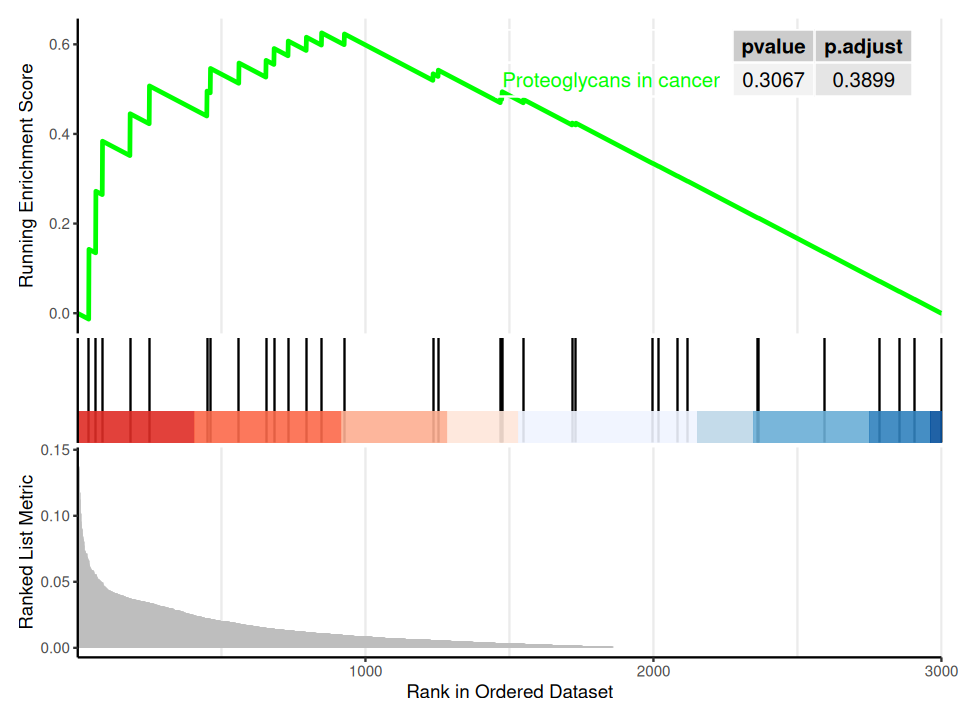

In [239]:
gseaplot2(gsea, geneSetID = 1, pvalue_table = TRUE)

#  Significantly enriched in the upper part of this pathway

# Positive values indicate enrichment at the top,
# and the genes to the left of the peak are core genes

#t he darker the red, the larger the weight of the gene at that position, 
# and the darker the blue, the smaller the weight

# bottom part display the signal-to-noise ratio (SNR) for each gene. 

# This is displayed as a gray area graph. The gray-shaded area ratio provides an overall picture of the magnitude of the Signal-to-noise between groups.


### apply GSEA in loop through each propgram

In [246]:
results_list <- list()

for (program in colnames(medoid_vectors)) {
  
  gene_stat <- medoid_vectors[, program]
  names(gene_stat) <- rownames(medoid_vectors)
  
  geneList <- sort(gene_stat, decreasing = TRUE) # ranm genes by weight 
  
  geneList <- geneList[!is.na(geneList)]
  geneList <- geneList[!duplicated(names(geneList))]

  gsea_res <- GSEA(
    geneList      = geneList,
    TERM2GENE     = TERM2GENE,
    pvalueCutoff  = 0.5,
    minGSSize     = 1,
    maxGSSize     = 500,
    pAdjustMethod = 'BH',
    by            = "fgsea",
    seed = TRUE,
    eps = 0  # if a more accure estimate of p value is desired, the eps parameter can be set as 0
  )

  results_list[[program]] <- gsea_res
}


using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (34.1% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are greater than zero and scoreType is "std", maybe you should switch to scoreType = "pos".”
no term enriched under specific pvalueCutoff...

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (35.63% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warnin

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (52.77% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are greater than zero and scoreType is "std", maybe you should switch to scoreType = "pos".”
no term enriched under specific pvalueCutoff...

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (38.93% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are gre

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are greater than zero and scoreType is "std", maybe you should switch to scoreType = "pos".”
no term enriched under specific pvalueCutoff...

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (48.53% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“All values in the stats vector are greater than zero and scoreType is "std", maybe you should switch to scoreType = "pos".”
leading edge analysis...

done...

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysi

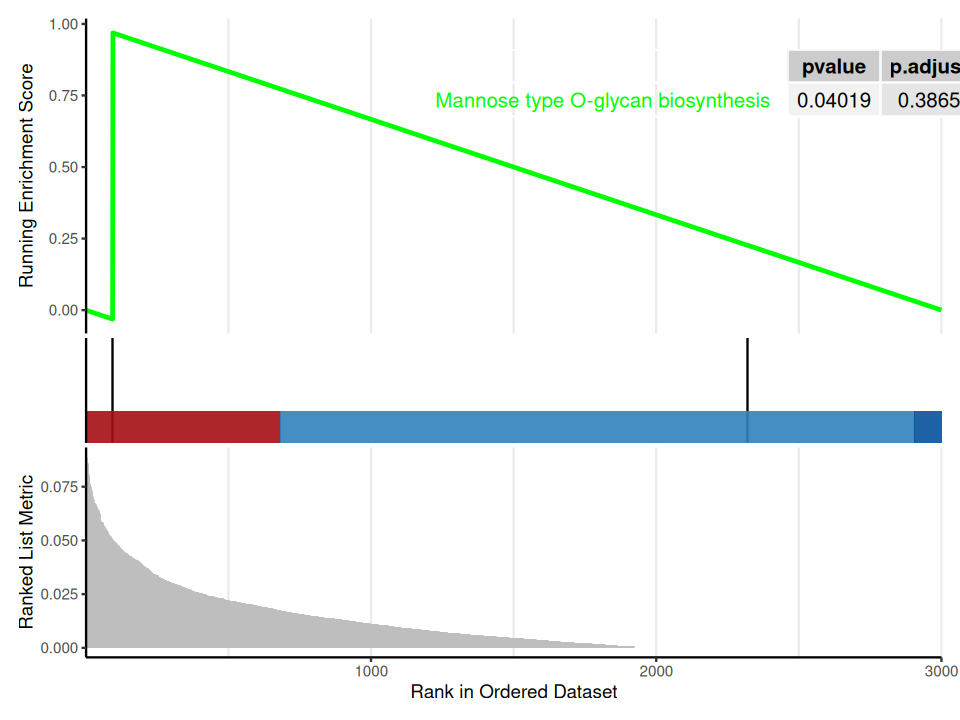

In [248]:
gseaplot2(results_list[['Patient02_SIGAE9_NG_Program_2']], geneSetID = 1, pvalue_table = TRUE)


In [249]:
length(results_list) # 31 programs

[1] 31

### function about loop through each program to draw an enrichment plot

In [214]:
library(clusterProfiler)
library(dplyr)
library(enrichplot)
library(ggplot2)

plot_all_gsea_results <- function(results_list, save_pdf = TRUE, out_dir = "GSEA_Plots") {
  #make sure the PDF save path exists 
  if (save_pdf && !dir.exists(out_dir)) dir.create(out_dir)

  for (pname in names(results_list)) {
    gsea <- results_list[[pname]] # gsea result of each program
    
    # Ensure results  exist
    df <- tryCatch(as.data.frame(gsea), error = function(e) return(NULL))
    if (is.null(df) || nrow(df) == 0) {
      message("No results for: ", pname)
      next
    }
    
    # Extract the valid pathway names
    valid_terms <- df %>%
      filter(!is.na(enrichmentScore) & pvalue < 0.2) %>% # here we set p value as 0.2 bec most of pathways not sig 
      arrange(p.adjust) %>%
      pull(ID)
    
    if (length(valid_terms) == 0) {
      message("No significant pathways for: ", pname)
      next
    }
    
    #  drawing function
    plot_obj <- tryCatch({
      gseaplot2(gsea,base_size = 16,
                geneSetID = valid_terms[1:length(valid_terms)],
                pvalue_table = TRUE,
                title = pname)
    }, error = function(e) {
      message("Plot failed for: ", pname, " | ", conditionMessage(e))
      return(NULL)
    })
    
    #  save 
    if (!is.null(plot_obj)) {
      if (save_pdf) {
          
          # Replace all non-alphanumeric characters in pname with underscores _
          # This is done to ensure that the file name is legal and to prevent unrecognizable symbols from appearing in the file system.

        file_path <- file.path(out_dir, paste0("GSEA_", gsub("[^A-Za-z0-9]", "_", pname), ".pdf"))
        ggsave(file_path, plot = plot_obj, width = 13, height = 7,dpi = 600)
      } else {
        print(plot_obj)
      }
    }
  }
}


No results for: SRR8513798_Program_4



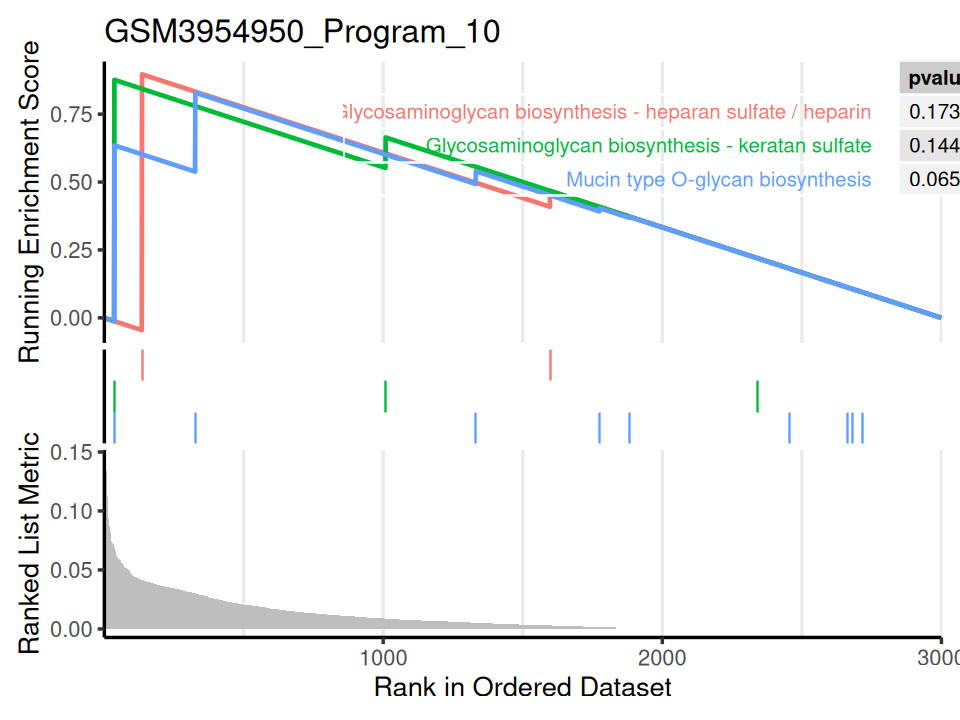

No results for: Patient16_SIGAA1_GIM_Program_1

No results for: GSM3954950_Program_3

No results for: GSM3954950_Program_8

No results for: Patient03_SIGAC5_BE_Program_12

No results for: GSM3954950_Program_4

No results for: GSM3954955_Program_8



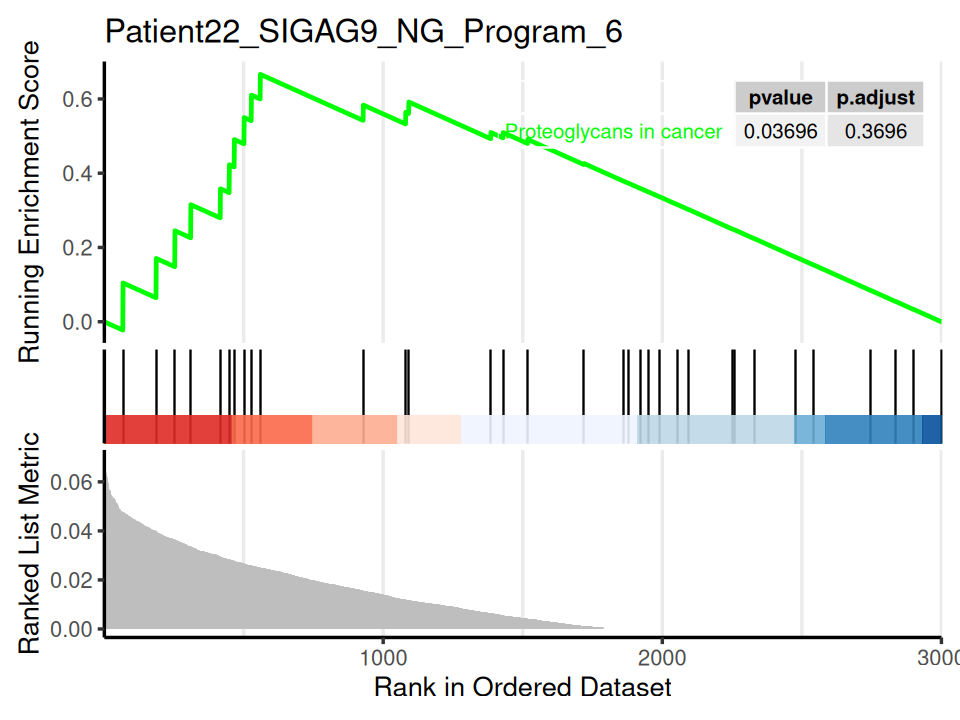

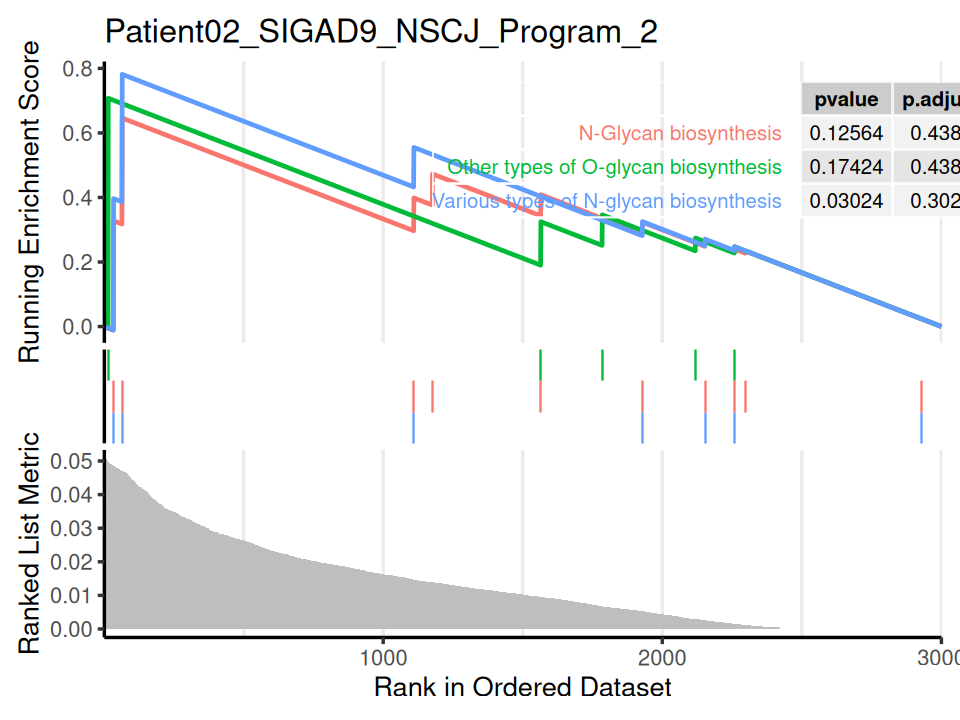

No results for: GSM3954950_Program_6

No results for: Patient21_SIGAB1_CIM_Program_2

No results for: Patient07_SIGAD4_NG_Program_8

No results for: Patient07_SIGAD4_NG_Program_7

No results for: Patient22_SIGAG9_NG_Program_14

No results for: Patient16_SIGAA1_GIM_Program_7



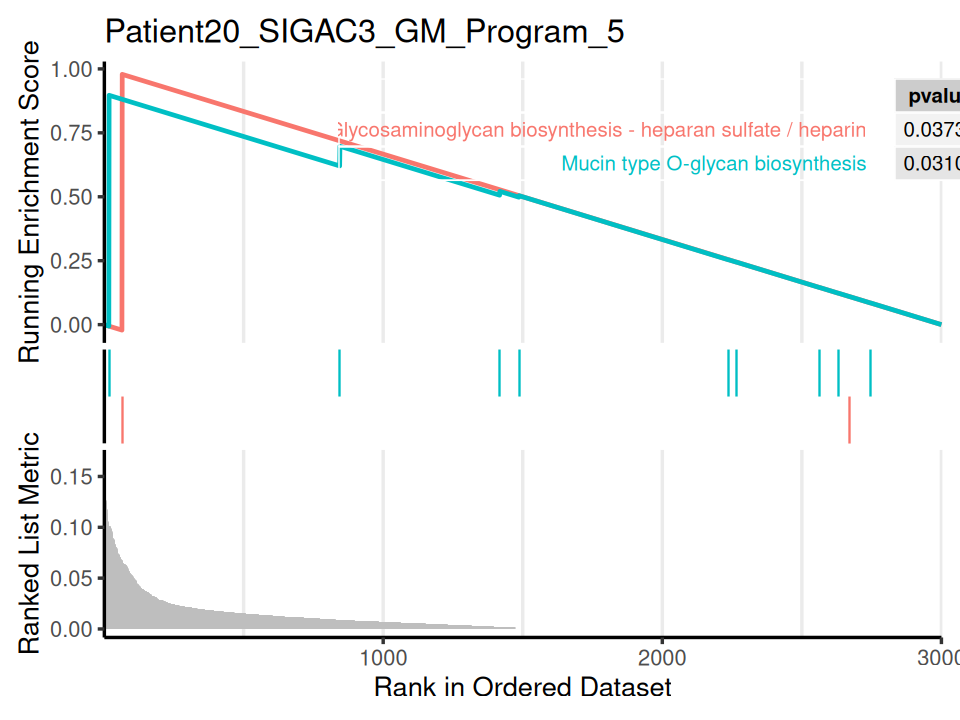

No results for: Patient02_SIGAD9_NSCJ_Program_1

No results for: Patient12_SIGAE3_ND_Program_1



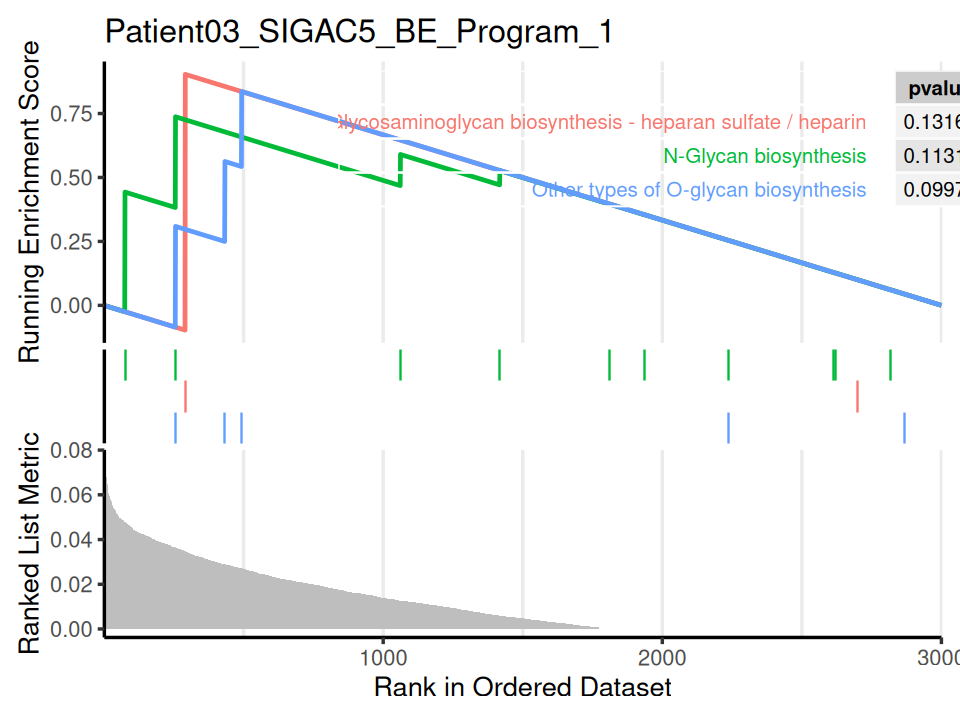

No results for: Patient16_SIGAA1_GIM_Program_8

No results for: Patient16_SIGAB1_CIM_Program_12



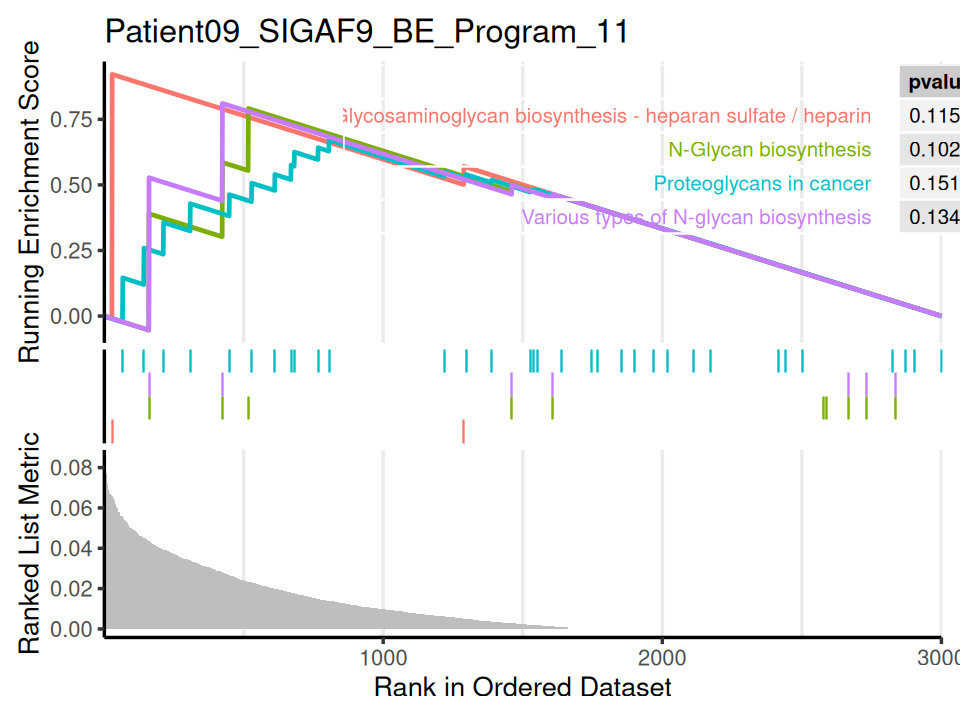

No results for: SRR8513797_Program_6



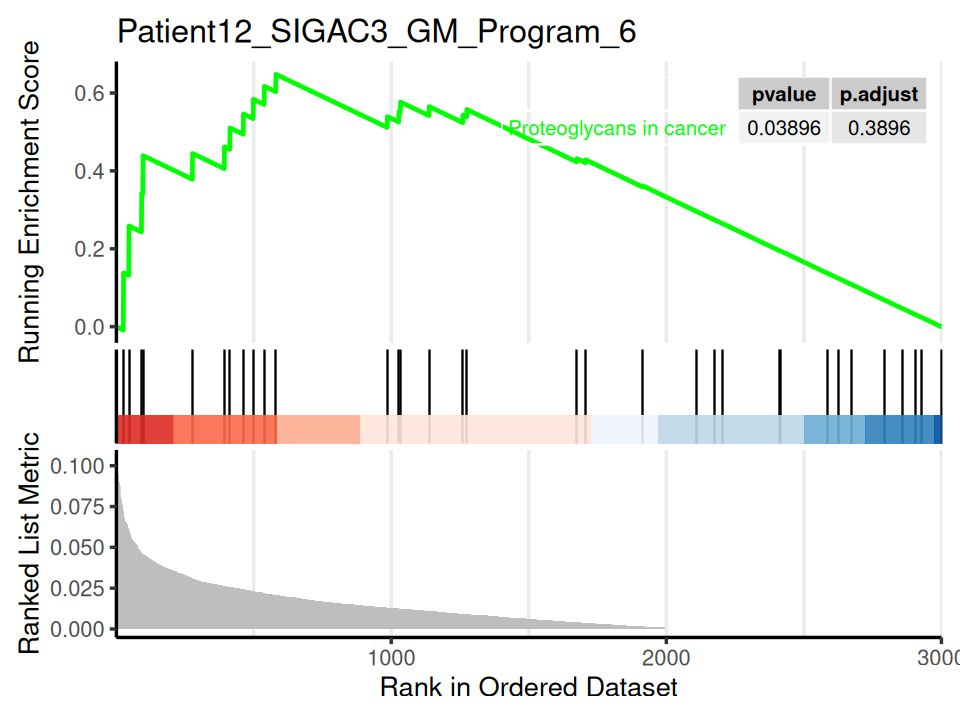

No results for: Patient14_SIGAE8_GIM_Program_13

No results for: Patient22_SIGAG9_NG_Program_3



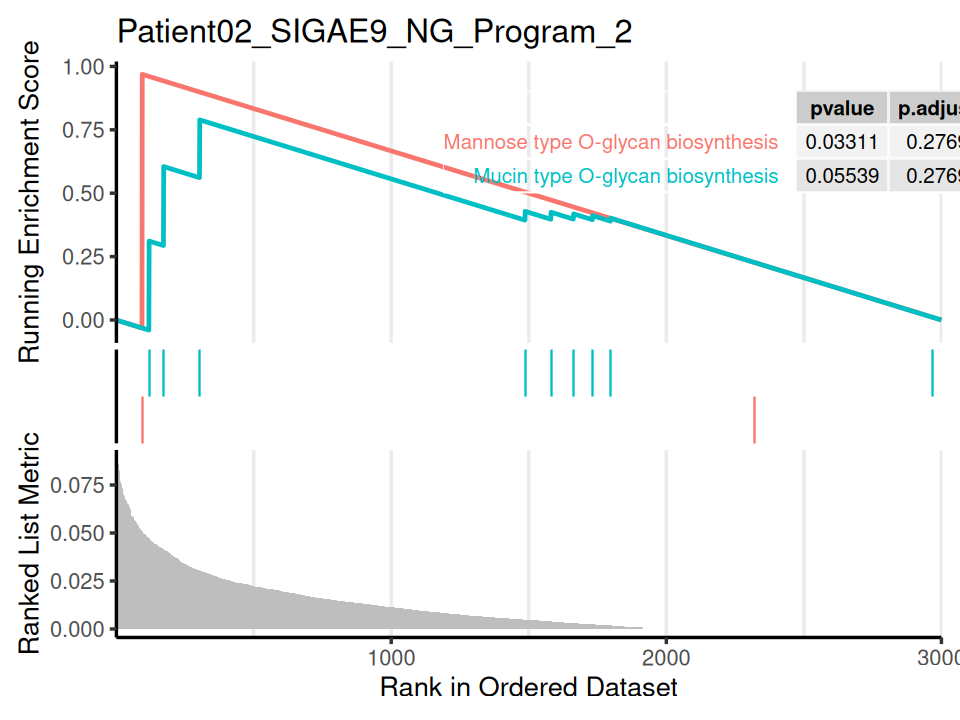

No results for: Patient22_SIGAG9_NG_Program_13

No results for: SRR8513797_Program_9

No results for: SRR8513798_Program_4

No results for: Patient16_SIGAA1_GIM_Program_1

No results for: GSM3954950_Program_3

No results for: GSM3954950_Program_8

No results for: Patient03_SIGAC5_BE_Program_12

No results for: GSM3954950_Program_4

No results for: GSM3954955_Program_8

No results for: GSM3954950_Program_6

No results for: Patient21_SIGAB1_CIM_Program_2

No results for: Patient07_SIGAD4_NG_Program_8

No results for: Patient07_SIGAD4_NG_Program_7

No results for: Patient22_SIGAG9_NG_Program_14

No results for: Patient16_SIGAA1_GIM_Program_7

No results for: Patient02_SIGAD9_NSCJ_Program_1

No results for: Patient12_SIGAE3_ND_Program_1

No results for: Patient16_SIGAA1_GIM_Program_8

No results for: Patient16_SIGAB1_CIM_Program_12

No results for: SRR8513797_Program_6

No results for: Patient14_SIGAE8_GIM_Program_13

No results for: Patient22_SIGAG9_NG_Program_3

No results for: Patient22

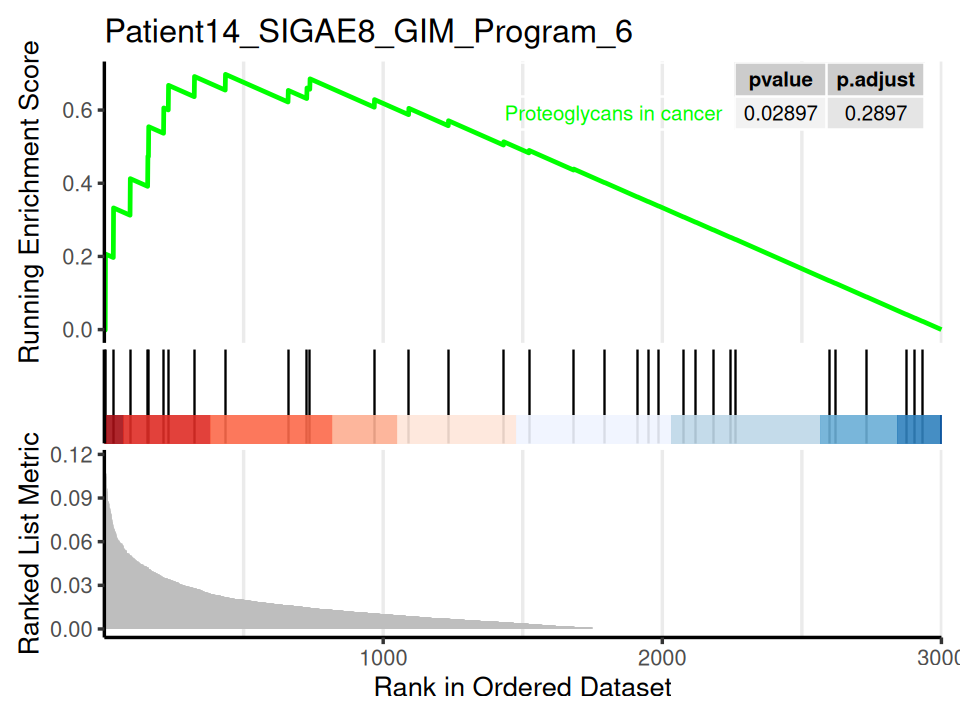

In [215]:
plot_all_gsea_results(results_list, save_pdf = FALSE)
plot_all_gsea_results(results_list,  save_pdf = TRUE, out_dir = "GSEA_Figures")
